# Start here

PSBD-ViT adapts Prediction Shift Backdoor Detection (PSBD, Li et al., arXiv 2406.05826), a backdoor detector published for ResNets, to Vision Transformers. The defender never sees the training data or the trigger. It holds a trained model and a small clean validation set, and it has to decide, 1 image at a time, whether that image carries a trigger. PSBD's answer is to run the model several times with a perturbation switched on, compare each perturbed prediction against the unperturbed one, and read a shifting prediction as a sign of a clean decision working properly. A decision that does not shift is read as resting on a shortcut, which is what a trigger gives a model.

This notebook is the index of the guided tour. It defines every term the later notebooks use, draws the architecture and the pipeline as diagrams, shows the 2 commands that produce a detection number, states which file on disk holds which number, and ends on the headline result drawn from those files. Every later notebook reads results rather than recomputing them, so after this one a reader can open any of them in any order. It runs on CPU in a few seconds and reads only `results/coverage/coverage.json`, `results/<folder>/psbd_metrics.json` and `paper/tables/*.macros.json`.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in the library resolves the
# same way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import json
import logging
import warnings

logging.getLogger("lightning.fabric.utilities.seed").setLevel(logging.WARNING)
# torchvision's ToTensor deprecation fires once per dataset load and says nothing
# about the numbers below.
warnings.filterwarnings("ignore", message="The transform `ToTensor", category=UserWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

import scripts.paper._style  # noqa: F401  the figure style every paper figure uses
from scripts.paper._common import word_list

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline


def macro(table, name):
    """1 value of paper/tables/<table>.macros.json, the string headline.tex prints."""
    with open(f"paper/tables/{table}.macros.json") as handle:
        sidecar = json.load(handle)
    value = sidecar["macros"][name]["value"]
    return value


def show_diagram(name, width=None):
    """Embed a TikZ diagram rendered by notebooks/figures/render.py."""
    display(Image(filename=f"notebooks/figures/{name}.png", width=width))

from defenses.decision import (
    ADAPTIVE_SHIFT_TARGET,
    HEADLINE_QUANTILE,
    PLACEMENT_MATCH_TARGET,
    PSBD_QUANTILES,
    PUBLISHED_PLACEMENT,
    RECOMMENDED_PLACEMENT,
)
from cli.sweep import DEFAULT_FORWARD_PASSES
from data.splits import PSBD_HELDOUT_SIZE
from models.positions import DROPOUT_CONFIGS, POSITION_REGISTRY
from scripts.paper._common import load_declaration

declaration = load_declaration("configs/psbd_basis.json")
# The masking and dropout operators share 1 kind of rate, a share of entries removed,
# so their ladders are the ones worth quoting together.
share_rates = [rate for entry in declaration["basis"] if entry["operator"] in ("dropout", "token_mask", "channel_mask") for rate in entry["rates"]]

print("repository root:", REPO_ROOT)

repository root: /lustre/home/pstika/projects/PSBD-ViT


## The model and the places a probe can attach

The question every later notebook asks is where inside a transformer a perturbation should be injected so that clean and triggered predictions react differently. Answering it needs a map of the block first.

ViT-B/16 cuts a $224\times224$ image into $14\times14=196$ patches of $16\times16$ pixels, embeds each patch as a 768-dimensional **token**, and prepends a learned **class token** (CLS), so every block carries a $(197, 768)$ tensor per image. The classifier head reads only the class token after the last of 12 **encoder blocks**. Each block is pre-norm: the **residual stream** $x$ passes a **LayerNorm** (LN, which rescales each token to zero mean and unit variance and then applies a learned affine map) into multi-head **self-attention**, the only operation that moves information between tokens, and the result is added back onto the stream. A second LayerNorm feeds a 2-layer **MLP**, whose output is added back again. The additions are the **residual adds**, and the path that bypasses a branch is the **skip**. The CIFAR, GTSRB and Tiny images are $32\times32$ or $64\times64$ and are resized to $224$, so a $3\times3$ pixel trigger covers about 4 tokens.

A **position** (the code also says site) is a named tensor boundary inside this block. `models/positions.py` holds 1 table per architecture, `POSITION_REGISTRY` and `plug_dropout` attaches a fresh perturbation module there through a forward hook, so no trained weight is touched and the model's own dropout stays off. The diagram marks every ViT position by its registry name.

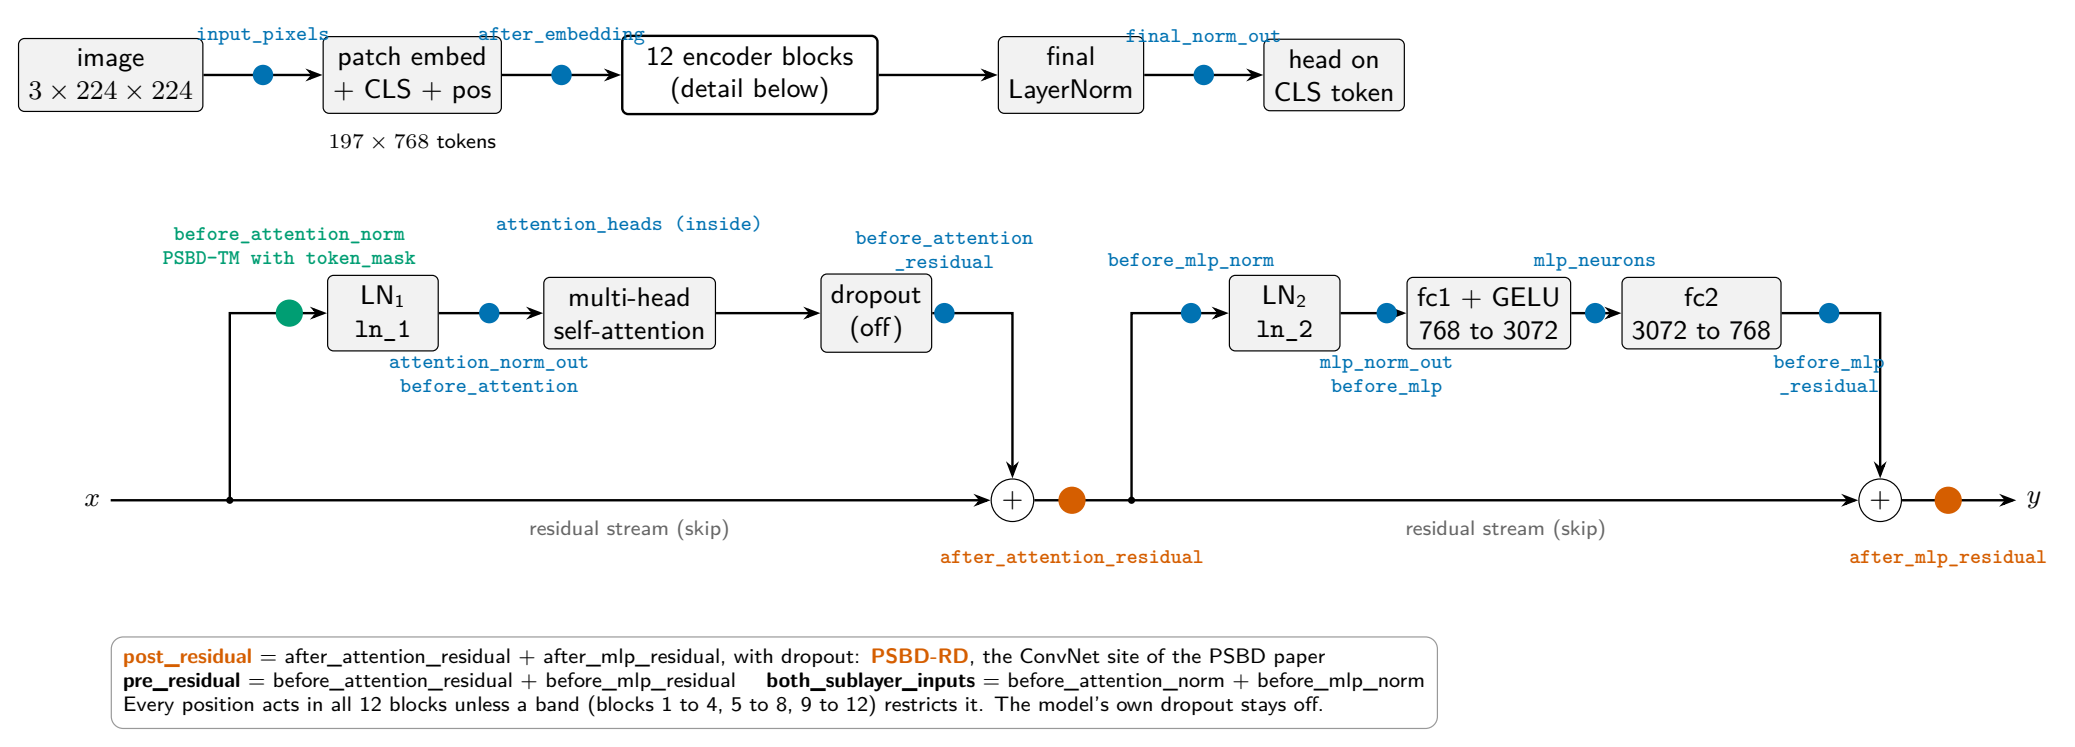

15 ViT positions in POSITION_REGISTRY['vit']:
  after_embedding              module 'encoder.dropout', hook 'pre', scope 'model'
  before_attention_norm        module 'ln_1', hook 'pre', scope 'block'
  before_attention             module 'self_attention', hook 'pre', scope 'block'
  attention_heads              module 'self_attention', hook 'attention', scope 'block'
  before_attention_residual    module 'dropout', hook 'post', scope 'block'
  before_mlp_norm              module 'ln_2', hook 'pre', scope 'block'
  after_attention_residual     module '', hook 'residual', scope 'block'
  before_mlp                   module 'mlp', hook 'pre', scope 'block'
  mlp_neurons                  module 'mlp.3', hook 'pre', scope 'block'
  before_mlp_residual          module 'mlp', hook 'post', scope 'block'
  after_mlp_residual           module '', hook 'post', scope 'block'
  attention_norm_out           module 'ln_1', hook 'post', scope 'block'
  mlp_norm_out                 module 'ln_2', hook

In [2]:
show_diagram("vit_block_positions")

vit_positions = POSITION_REGISTRY["vit"]
print(f"{len(vit_positions)} ViT positions in POSITION_REGISTRY['vit']:")
for name, spec in vit_positions.items():
    print(f"  {name:28s} module '{spec.submodule_name}', hook '{spec.hook_type}', scope '{spec.scope}'")
print("\ncomposite positions, models.positions.DROPOUT_CONFIGS:")
for name, parts in DROPOUT_CONFIGS.items():
    print(f"  {name:22s} = {' + '.join(parts)}")

The diagram shows the order in which a token meets each position, and which positions sit on a branch (blue, the skip is untouched) and which sit on the stream (orange, both the next branch and the skip see the change). It does not show the strength of a perturbation or which position works. Those are measured quantities and `placement-walk.ipynb` reads them. The 2 positions drawn inside a module, `attention_heads` and `after_attention_residual`, cannot be reached by a hook, because the tensor they perturb never crosses a module boundary, so `models.positions` swaps in a removable per-instance forward instead. The question the map raises is what a perturbation at 1 of these points does to a prediction, which the vocabulary below makes precise.

## Vocabulary

In [3]:
display(Markdown(rf"""
A **perturbation**, called the **operator** in the code (`defenses/operators.py`), is what the hook does to the tensor at a position: dropout (zero single entries independently and rescale the rest by $1/(1-p)$), token masking (zero whole tokens, rescale the rest, never the class token), channel masking (zero whole channels shared across tokens), additive Gaussian noise, head masking, drop path or gain scaling of a LayerNorm output. A **placement** names a position together with an operator, and it is also the name of the cache directory, for example `before_attention_norm_token_mask`. A placement id with no operator suffix, such as `post_residual`, means dropout. A **rate** $p$ is the operator's own strength parameter, swept over a ladder that for the masking and dropout operators runs from {min(share_rates)} to {max(share_rates)} depending on the placement.

A **sweep** runs 1 placement on 1 model over its rate ladder and stores every per-pass prediction. An **analysis** reads that cache and writes the detection metrics. The **basis** is the declared set of placements swept on every model, listed in `configs/psbd_basis.json`. A **band** restricts a placement to a range of blocks (1 to 4, 5 to 8 or 9 to 12) and a placement with no band acts in every block. $k$ is the number of perturbed **forward passes** per image, {DEFAULT_FORWARD_PASSES} by default (`cli.sweep.DEFAULT_FORWARD_PASSES`) as in the PSBD paper.

On the attack side, the **poison rate** is the share of training images an attack stamps with its trigger, the **attack success rate** (ASR) is the share of triggered test images from a non-target class that the model sends to the target, and **clean accuracy** is accuracy on unmodified test images. A model **clears** when its ASR reaches the bar of {declaration['asr_bar']} in `configs/psbd_basis.json`. Only clearing models enter a detection number, because a detector cannot be asked to find a backdoor that was never implanted.

On the detection side, a triggered image is the positive class. **AUROC** is the probability that a random triggered image scores lower than a random clean image, with 0.5 as chance and it needs no threshold. **TPR** (true-positive rate) is the share of triggered images flagged, and **FPR** (false-positive rate) the share of clean images flagged, both at a threshold.
"""))


A **perturbation**, called the **operator** in the code (`defenses/operators.py`), is what the hook does to the tensor at a position: dropout (zero single entries independently and rescale the rest by $1/(1-p)$), token masking (zero whole tokens, rescale the rest, never the class token), channel masking (zero whole channels shared across tokens), additive Gaussian noise, head masking, drop path or gain scaling of a LayerNorm output. A **placement** names a position together with an operator, and it is also the name of the cache directory, for example `before_attention_norm_token_mask`. A placement id with no operator suffix, such as `post_residual`, means dropout. A **rate** $p$ is the operator's own strength parameter, swept over a ladder that for the masking and dropout operators runs from 0.005 to 0.99 depending on the placement.

A **sweep** runs 1 placement on 1 model over its rate ladder and stores every per-pass prediction. An **analysis** reads that cache and writes the detection metrics. The **basis** is the declared set of placements swept on every model, listed in `configs/psbd_basis.json`. A **band** restricts a placement to a range of blocks (1 to 4, 5 to 8 or 9 to 12) and a placement with no band acts in every block. $k$ is the number of perturbed **forward passes** per image, 3 by default (`cli.sweep.DEFAULT_FORWARD_PASSES`) as in the PSBD paper.

On the attack side, the **poison rate** is the share of training images an attack stamps with its trigger, the **attack success rate** (ASR) is the share of triggered test images from a non-target class that the model sends to the target, and **clean accuracy** is accuracy on unmodified test images. A model **clears** when its ASR reaches the bar of 0.85 in `configs/psbd_basis.json`. Only clearing models enter a detection number, because a detector cannot be asked to find a backdoor that was never implanted.

On the detection side, a triggered image is the positive class. **AUROC** is the probability that a random triggered image scores lower than a random clean image, with 0.5 as chance and it needs no threshold. **TPR** (true-positive rate) is the share of triggered images flagged, and **FPR** (false-positive rate) the share of clean images flagged, both at a threshold.


## The 2 named placements

2 placements carry names of their own, because the paper's whole argument is a comparison between them. **PSBD-RD** (residual dropout) applies dropout to the residual stream after both residual adds, `post_residual`, the closest a ViT block comes to the original ResNet placement, which applied dropout after the residual add inside the basic block. **PSBD-TM** (token masking) masks whole tokens at the attention input, before the LayerNorm that feeds self-attention, `before_attention_norm_token_mask`. The diagram contrasts what the 2 operators remove and where the 2 placements act.

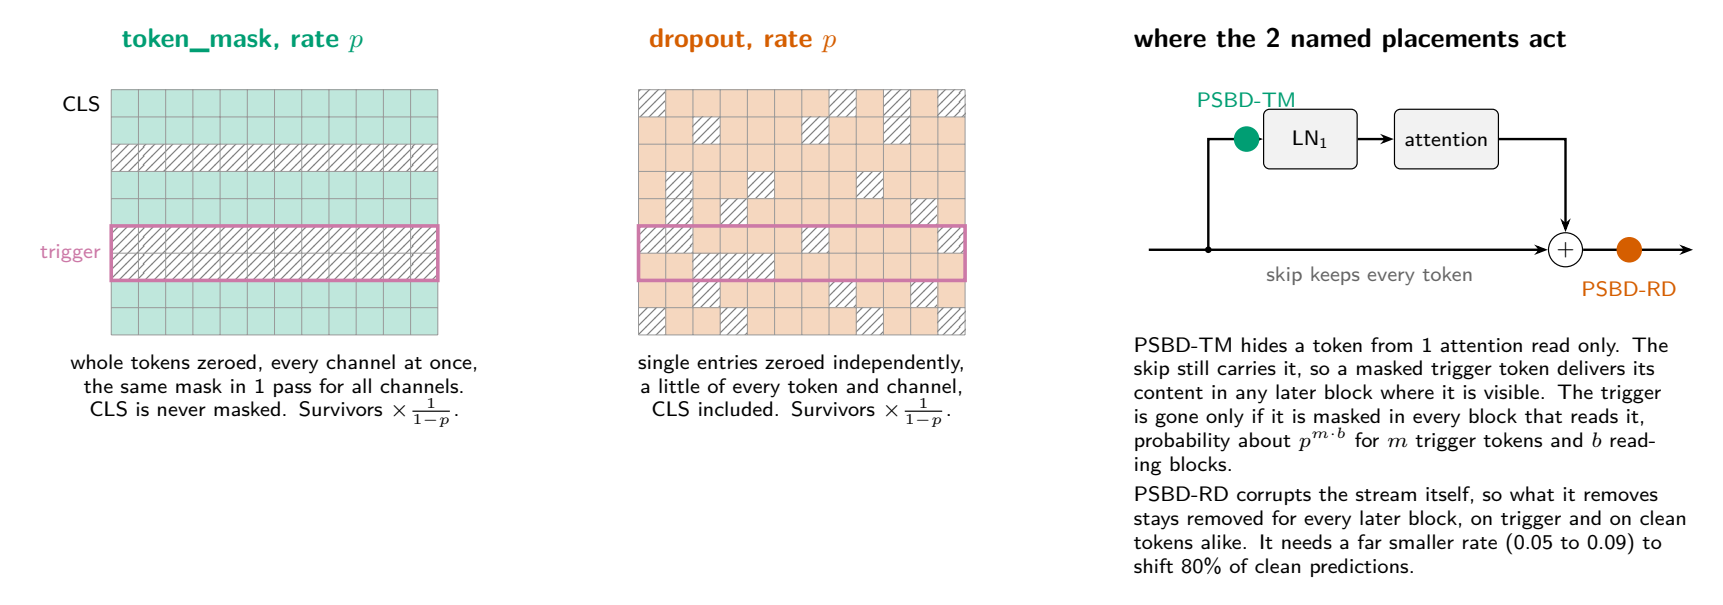

PSBD-TM placement id, defenses.decision.RECOMMENDED_PLACEMENT: before_attention_norm_token_mask
PSBD-RD placement id, defenses.decision.PUBLISHED_PLACEMENT:   post_residual
PSBD-RD positions: ('after_attention_residual', 'after_mlp_residual')


In [4]:
show_diagram("token_mask_vs_dropout")
assert RECOMMENDED_PLACEMENT == "before_attention_norm_token_mask"
assert PUBLISHED_PLACEMENT == "post_residual"
print(f"PSBD-TM placement id, defenses.decision.RECOMMENDED_PLACEMENT: {RECOMMENDED_PLACEMENT}")
print(f"PSBD-RD placement id, defenses.decision.PUBLISHED_PLACEMENT:   {PUBLISHED_PLACEMENT}")
print(f"PSBD-RD positions: {DROPOUT_CONFIGS[PUBLISHED_PLACEMENT]}")

The left 2 panels are toy grids of 9 tokens by 12 channels, and the hatched cells are zeroed. Token masking removes rows, dropout removes scattered cells. The right panel is the part that matters for a trigger. PSBD-TM hides a token from 1 attention read and leaves the skip intact, so a trigger token masked in block 3 still carries its content into block 4. PSBD-RD corrupts the stream itself, so whatever it removes is gone for every later block. The diagram does not say which of the 2 detects better, and it does not show that the effect depends on the attack. `mechanism.ipynb` measures both claims, and `placement-walk.ipynb` separates the position from the operator.

## The score and the decision

The detection statistic is the prediction shift uncertainty, PSU, the drop in the probability the model assigned its own unperturbed prediction, averaged over the $k$ perturbed passes. This repository scores the fractional form, which divides the drop by the starting confidence (`defenses.scores.psu_ratio_from_cache`), and reports the paper's absolute form beside it (`psu_from_cache`):

$$\varphi(x) = 1 - \frac{1}{k}\sum_{i=1}^{k} \frac{P_c(x; p, \theta_i')}{P_c(x; \theta)}, \qquad c = \arg\max_j P_j(x; \theta)$$

| symbol | meaning |
|---|---|
| $x$ | 1 input image |
| $\theta$ | the trained weights, unperturbed |
| $\theta_i'$ | the same weights with the perturbation drawn afresh on pass $i$ |
| $p$ | the operator's rate |
| $k$ | number of perturbed passes |
| $P_j(x;\theta)$ | softmax probability of class $j$ |
| $c$ | the unperturbed predicted class |
| $\varphi(x)$ | fractional PSU, 0 when the prediction did not move at all |

In [5]:
display(Markdown(rf"""
A low PSU means the prediction barely moved under the perturbation. The decision rule is 1-sided, so a low PSU is read as poisoned. The threshold $\tau$ is the {HEADLINE_QUANTILE:.0%} quantile of PSU on {PSBD_HELDOUT_SIZE} clean validation images (`data.splits.PSBD_HELDOUT_SIZE`), so about {HEADLINE_QUANTILE:.0%} of clean images are flagged by construction, and the analysis also reads the quantiles {", ".join(f"{q:.0%}" for q in PSBD_QUANTILES[:-2])} and {PSBD_QUANTILES[-2]:.0%} (`PSBD_QUANTILES`). The rate a placement is read at is chosen by a rule stated in advance and never picked after seeing detection numbers: the smallest rate whose clean validation predictions shift {ADAPTIVE_SHIFT_TARGET:.0%} of the time. The **shift ratio** $\sigma(p)$ is that share of (image, pass) predictions that moved, `defenses.scores.shift_ratio`. The deployable rule is `defenses.decision.select_rate_adaptively` at `ADAPTIVE_SHIFT_TARGET` {ADAPTIVE_SHIFT_TARGET}. Comparisons between placements use a second rule, `select_rate_at_matched_shift` at `PLACEMENT_MATCH_TARGET` {PLACEMENT_MATCH_TARGET}, so 2 placements are read at the same measured disturbance.
"""))


A low PSU means the prediction barely moved under the perturbation. The decision rule is 1-sided, so a low PSU is read as poisoned. The threshold $\tau$ is the 25% quantile of PSU on 2000 clean validation images (`data.splits.PSBD_HELDOUT_SIZE`), so about 25% of clean images are flagged by construction, and the analysis also reads the quantiles 1%, 5%, 10%, 15% and 20% (`PSBD_QUANTILES`). The rate a placement is read at is chosen by a rule stated in advance and never picked after seeing detection numbers: the smallest rate whose clean validation predictions shift 80% of the time. The **shift ratio** $\sigma(p)$ is that share of (image, pass) predictions that moved, `defenses.scores.shift_ratio`. The deployable rule is `defenses.decision.select_rate_adaptively` at `ADAPTIVE_SHIFT_TARGET` 0.8. Comparisons between placements use a second rule, `select_rate_at_matched_shift` at `PLACEMENT_MATCH_TARGET` 0.6, so 2 placements are read at the same measured disturbance.


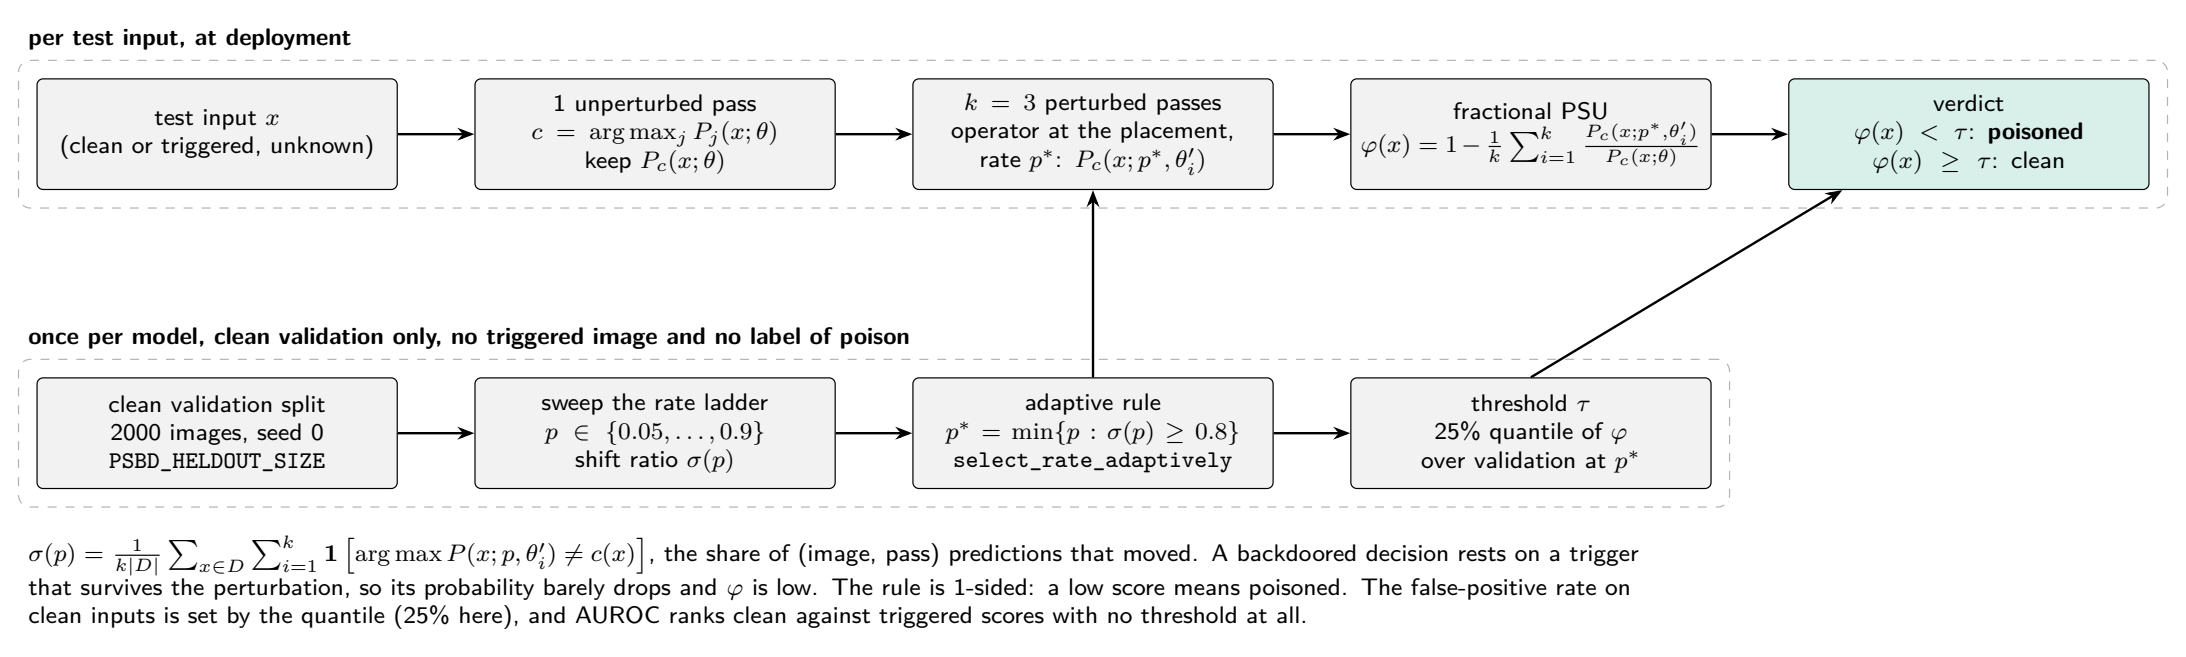

deployable rate rule targets a shift ratio of 0.8
cross-placement comparisons are read at a matched shift ratio of 0.6
clean-validation threshold at the 25% quantile, headline
every quantile the analysis writes: (0.01, 0.05, 0.1, 0.15, 0.2, 0.25)


In [6]:
show_diagram("psbd_pipeline")

print(f"deployable rate rule targets a shift ratio of {ADAPTIVE_SHIFT_TARGET}")
print(f"cross-placement comparisons are read at a matched shift ratio of {PLACEMENT_MATCH_TARGET}")
print(f"clean-validation threshold at the {HEADLINE_QUANTILE:.0%} quantile, headline")
print(f"every quantile the analysis writes: {PSBD_QUANTILES}")

In [7]:
display(Markdown(rf"""
The top row runs for every test input, the bottom row once per model on clean images only, so the defender never needs a triggered image or a poison label to set the rate or the threshold. The diagram does not show the rate ladder of each placement, which differs (on the headline panel the adaptive rule picks a mean rate of {macro("survival", "SurvivalRdRate")} for dropout on the stream and {macro("survival", "SurvivalTmRate")} for token masking, `\SurvivalRdRate` and `\SurvivalTmRate`) and it does not show that the FPR on the test set only approximates the quantile. `psbd-end-to-end.ipynb` runs every box of this diagram on 1 model from its cache and draws each intermediate quantity.
"""))


The top row runs for every test input, the bottom row once per model on clean images only, so the defender never needs a triggered image or a poison label to set the rate or the threshold. The diagram does not show the rate ladder of each placement, which differs (on the headline panel the adaptive rule picks a mean rate of 0.07 for dropout on the stream and 0.54 for token masking, `\SurvivalRdRate` and `\SurvivalTmRate`) and it does not show that the FPR on the test set only approximates the quantile. `psbd-end-to-end.ipynb` runs every box of this diagram on 1 model from its cache and draws each intermediate quantity.


## Running 1 sweep and 1 analysis

Every detection number in the paper traces back to these 2 commands, run from the repository root with the virtual environment active:

```bash
python -m cli.sweep \
    --checkpoint checkpoints/vit_cifar100_badnet_a2o_0_01 \
    --position before_attention_norm --operator token_mask
python -m cli.analyze --folder vit_cifar100_badnet_a2o_0_01
```

`cli.sweep` needs a GPU. It loads the checkpoint, attaches the placement, runs the perturbed passes at every rate on the ladder, and writes the raw per-pass probabilities under `results/<folder>/psbd/<placement>/`, with a `run_<placement>.json` file recording the rate ladder, $k$, the seeds and the commit. `cli.analyze` runs on CPU. It reads that cache, applies every threshold rule and writes `results/<folder>/psbd_metrics.json`, 1 entry per placement. `psbd-end-to-end.ipynb` repeats the analysis step on 1 model from the same cache.

## Which command writes which file

| file | written by | read by |
|---|---|---|
| `checkpoints/<folder>/attack_result.pt`, `args.json` | `cli.train_backdoor`, `cli.train_benign` | every command below |
| `checkpoints/<folder>/metrics.json` | `cli.evaluate` | the coverage ledger |
| `results/<folder>/psbd/<placement>/*.pt` | `cli.sweep` | `cli.analyze`, `psbd-end-to-end.ipynb` |
| `results/<folder>/psbd_metrics.json` | `cli.analyze` | `scripts/paper/*.py`, most notebooks |
| `results/<folder>/detectors/<name>_metrics.json` | `cli.baselines` | `scripts/paper/tab_detectors.py`, `detectors-per-attack.ipynb` |
| `results/coverage/coverage.json` | `scripts/coverage_ledger.py` | `scripts/paper/*.py`, every panel notebook |
| `paper/tables/*.tex`, `*.macros.json` | `scripts/paper/tab_*.py`, `fig_*.py`, `mech_*.py` | `paper/headline.tex`, the notebooks' number checks |

The diagram draws the same table as a graph. Every notebook past this one reads from `results/` rather than recomputing a sweep, and checks the numbers its markdown states against the macro sidecars under `paper/tables/`.

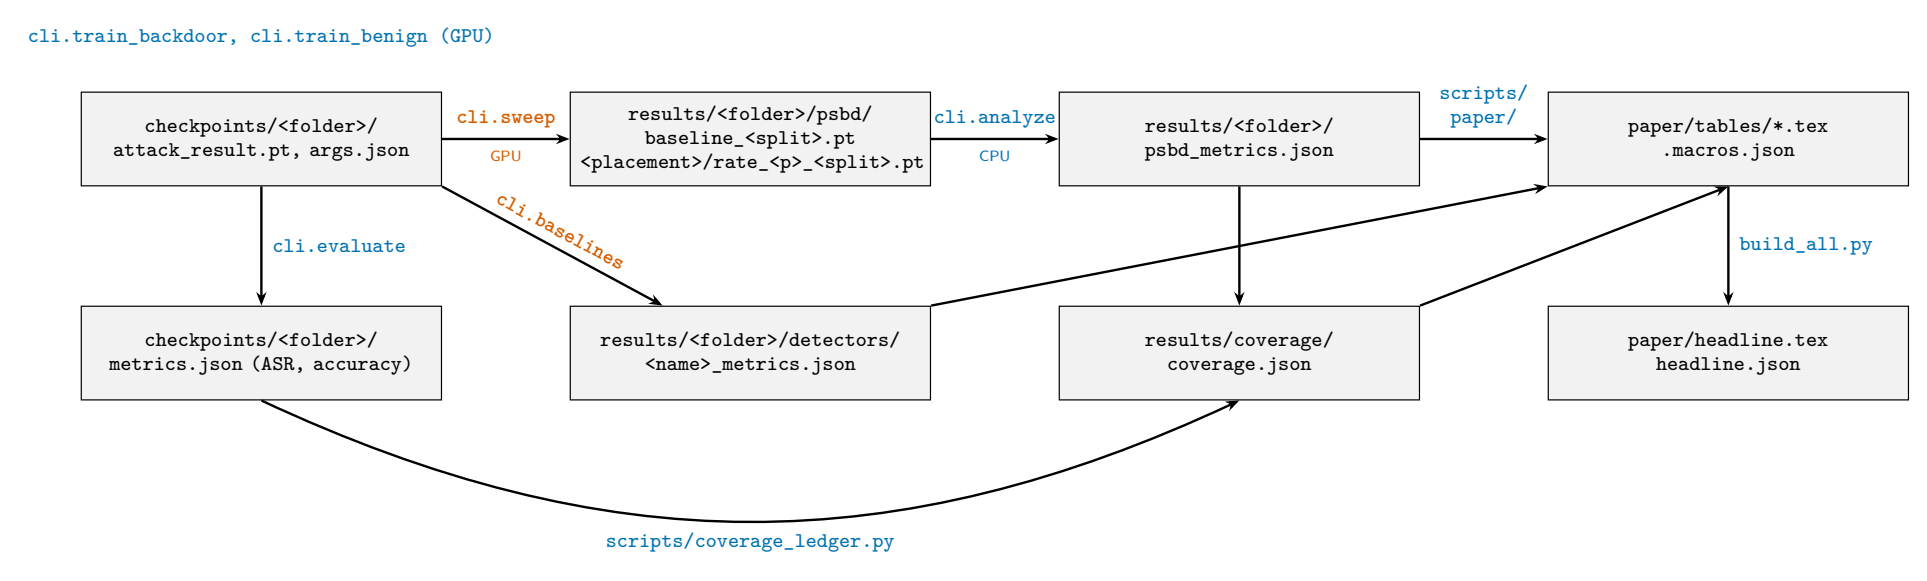

In [8]:
show_diagram("data_flow")

## The model panel

A detection number is a mean over models, so the first thing to know is which models. `scripts/coverage_ledger.py` writes 1 record per trained checkpoint to `results/coverage/coverage.json`, and `scripts.paper._common.load_coverage` keeps the 4 datasets the paper reports (CIFAR-10, CIFAR-100, GTSRB and Tiny ImageNet, the `panel.datasets` of `configs/psbd_basis.json`). Each record carries an `asr_class`. `clears` means ASR at least 0.85. `below_bar` means the attack did not implant. `diverged` means clean accuracy fell below half the benign reference, a collapsed model. `source_mapped` marks TaCT models whose clean source class is already sent to another class with no trigger, so the ASR measures a class mapping rather than a trigger, and the ledger excludes them. A `clears` model is counted in the results only when it is also a successful backdoor, `successful_2pt`: its clean accuracy is within the headline bar (`clean_accuracy_drop_bar_headline` of `configs/psbd_basis.json`, the bar the literature uses) of the benign model trained on the same data, because a backdoor that costs more accuracy than that would be noticed without any detector.

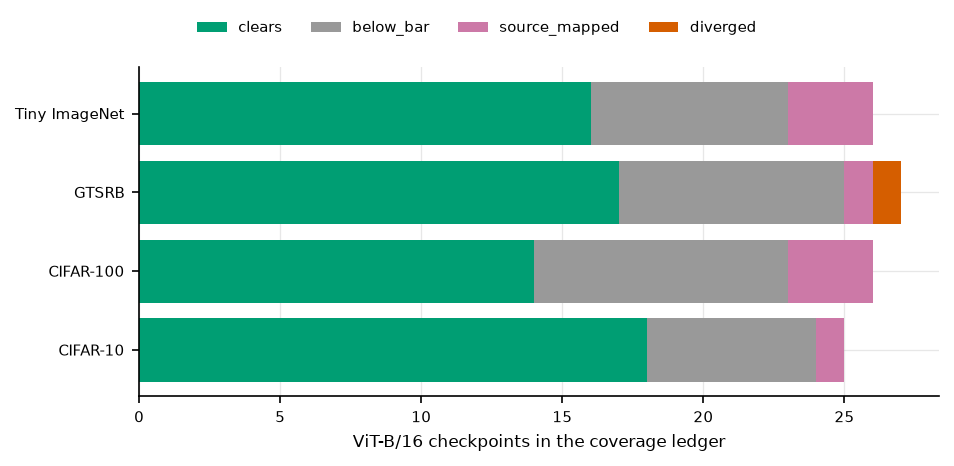

ledger written 2026-09-30T12:54:51+00:00
104 panel cells, 65 clear the 0.85 bar, 62 of them successful, 8 source-mapped TaCT cells excluded


asr_class,clears,below_bar,source_mapped,diverged,total
dataset,,,,,
cifar10,18,6,1,0,25
cifar100,14,9,3,0,26
gtsrb,17,8,1,1,27
tiny,16,7,3,0,26


In [9]:
from scripts.paper._common import (
    clearing_cells,
    dataset_label,
    implanted_cells,
    load_coverage,
)
from scripts.paper._style import legend_above

coverage = load_coverage("results")
ledger = pd.DataFrame(coverage["cells"])
class_order = ["clears", "below_bar", "source_mapped", "diverged"]
counts = (
    ledger.groupby(["dataset", "asr_class"]).size().unstack(fill_value=0)
    .reindex(columns=class_order, fill_value=0)
)  # (datasets, classes)

figure, axis = plt.subplots(figsize=(6.4, 2.8))
left = np.zeros(len(counts))  # (datasets,)
for asr_class, color in zip(class_order, ["#009E73", "#999999", "#CC79A7", "#D55E00"]):
    axis.barh([dataset_label(d) for d in counts.index], counts[asr_class], left=left, color=color, label=asr_class)
    left += counts[asr_class].to_numpy()
axis.set_xlabel("ViT-B/16 checkpoints in the coverage ledger")
figure.tight_layout()
legend_above(figure, [axis], columns=4)
plt.show()

total_cells = len(ledger)
clearing = len(implanted_cells(coverage))
successful = len(clearing_cells(coverage))
source_mapped = int((ledger["asr_class"] == "source_mapped").sum())
assert str(total_cells) == macro("panel", "PanelCellsTotal")
assert str(clearing) == macro("panel", "PanelCellsClearing")
assert str(successful) == macro("panel", "PanelCellsSuccessful")
assert str(source_mapped) == macro("panel", "PanelCellsSourceMapped")
print(f"ledger written {coverage['generated_at']}")
print(f"{total_cells} panel cells, {clearing} clear the {coverage['asr_bar']} bar, "
      f"{successful} of them successful, {source_mapped} source-mapped TaCT cells excluded")
counts.assign(total=counts.sum(axis=1))

In [10]:
display(Markdown(rf"""
The ledger holds {total_cells} ViT-B/16 cells on the {len(counts)} panel datasets, and {clearing} clear the bar. {successful} of those keep their clean accuracy within {macro("panel", "PanelCleanBarPoints")} points of the benign model and are the models every result is computed over, and the {clearing - successful} left out are {macro("panel", "PanelCellsFailingCleanBarNames").replace(chr(92) + "%", "%")}. The asserts above hold the counts to the macros `\PanelCellsTotal`, `\PanelCellsClearing`, `\PanelCellsSuccessful` and `\PanelCellsSourceMapped` of `paper/tables/panel.macros.json`, written by `scripts/paper/tab_panel.py`, so the figure and the paper cannot disagree without this cell failing. The figure does not show which attacks and rates the cells hold, which `data-and-attacks.ipynb` breaks out. It also does not show the Swin-S models, which have no ledger of their own and are read by `swin-and-robustness.ipynb`. The next question is what PSBD scores on the successful cells.
"""))


The ledger holds 104 ViT-B/16 cells on the 4 panel datasets, and 65 clear the bar. 62 of those keep their clean accuracy within 2 points of the benign model and are the models every result is computed over, and the 3 left out are SIG at 10% on CIFAR-10, WaNet at 5% on CIFAR-10 and WaNet at 10% on GTSRB. The asserts above hold the counts to the macros `\PanelCellsTotal`, `\PanelCellsClearing`, `\PanelCellsSuccessful` and `\PanelCellsSourceMapped` of `paper/tables/panel.macros.json`, written by `scripts/paper/tab_panel.py`, so the figure and the paper cannot disagree without this cell failing. The figure does not show which attacks and rates the cells hold, which `data-and-attacks.ipynb` breaks out. It also does not show the Swin-S models, which have no ledger of their own and are read by `swin-and-robustness.ipynb`. The next question is what PSBD scores on the successful cells.


## The headline in 1 figure

The headline panel is every successful cell on which both named placements reached the adaptive rule and PSBD-TM also reached the matched rule, `scripts.paper.tab_staircase.panel_cells`, the same common-coverage filter `scripts/paper/tab_headline.py` applies. Each point below is 1 model, AUROC at the adaptive rule and the 25% quantile on the fractional PSU, PSBD-RD on the x axis and PSBD-TM on the y axis. A point above the diagonal is a model where PSBD-TM separates better.

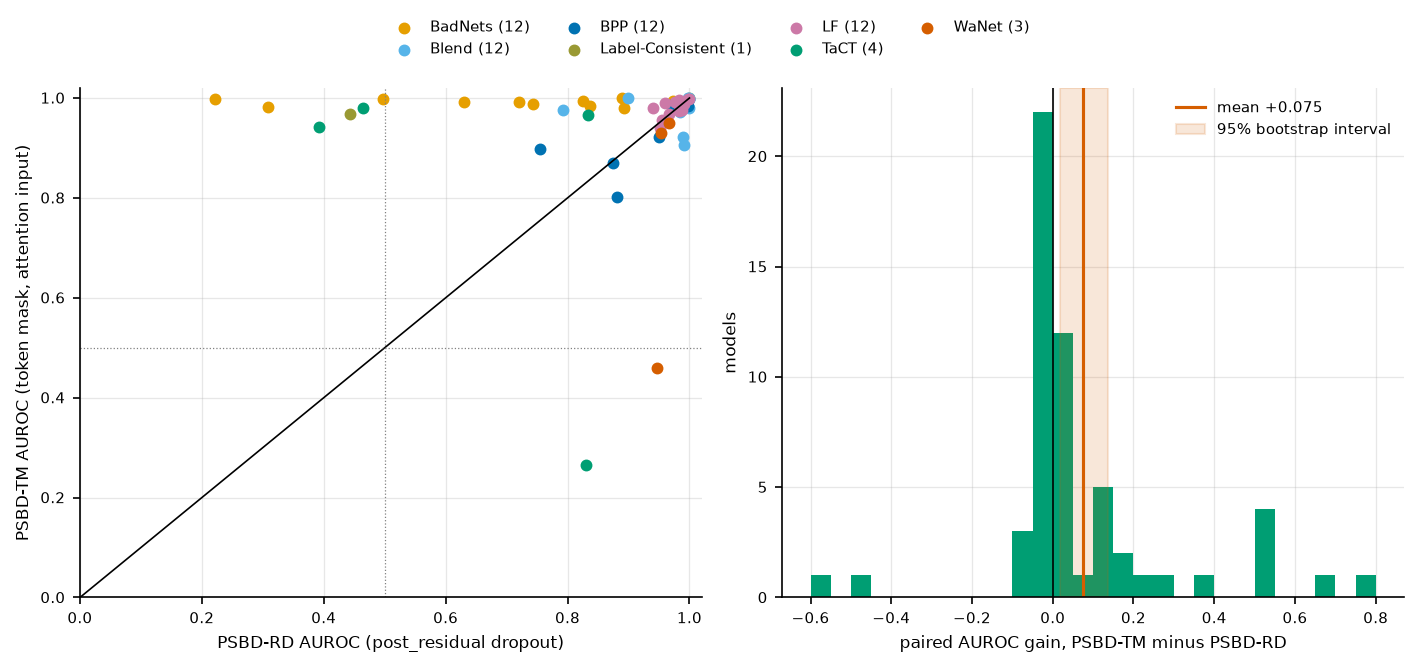

56 models, PSBD-TM 0.951, PSBD-RD 0.876
paired gain +0.075 [+0.017, +0.138], PSBD-TM ahead on 29 of 56 models
PSBD-TM floor 0.266, below chance on 2 models


In [11]:
from cli.compare_detectors import psbd_values
from scripts.paper._common import (
    BOOTSTRAP_RESAMPLES,
    BOOTSTRAP_SEED,
    HEADLINE_KEY,
    attack_label,
    bootstrap_ci,
    fmt,
)
from scripts.paper._style import attack_color, legend_above
from scripts.paper.tab_staircase import panel_cells

panel = panel_cells("results", coverage)
headline = pd.DataFrame(
    [
        {
            "folder": cell["folder_name"],
            "attack": cell["attack"],
            "dataset": cell["dataset"],
            "poison_rate": cell["poison_rate"],
            "tm": psbd_values(cell["report"], RECOMMENDED_PLACEMENT, "adaptive")[HEADLINE_KEY]["auroc"],
            "rd": psbd_values(cell["report"], PUBLISHED_PLACEMENT, "adaptive")[HEADLINE_KEY]["auroc"],
        }
        for cell in panel
    ]
)
gain = headline["tm"] - headline["rd"]  # (models,)
gain_low, gain_high = bootstrap_ci(gain.tolist(), BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED)

figure, (scatter_axis, gain_axis) = plt.subplots(1, 2, figsize=(9.5, 4.0))
for attack, rows in headline.groupby("attack"):
    scatter_axis.scatter(rows["rd"], rows["tm"], s=22, color=attack_color(attack), label=f"{attack_label(attack)} ({len(rows)})")
scatter_axis.plot([0, 1], [0, 1], color="black", lw=0.8)
scatter_axis.axhline(0.5, color="gray", lw=0.6, ls=":")
scatter_axis.axvline(0.5, color="gray", lw=0.6, ls=":")
scatter_axis.set_xlabel("PSBD-RD AUROC (post_residual dropout)")
scatter_axis.set_ylabel("PSBD-TM AUROC (token mask, attention input)")
scatter_axis.set_xlim(0, 1.02)
scatter_axis.set_ylim(0, 1.02)

gain_axis.hist(gain, bins=np.linspace(-0.6, 0.8, 29), color="#009E73")
gain_axis.axvline(0, color="black", lw=0.8)
gain_axis.axvline(gain.mean(), color="#D55E00", lw=1.5, label=f"mean {gain.mean():+.3f}")
gain_axis.axvspan(gain_low, gain_high, color="#D55E00", alpha=0.15, label="95% bootstrap interval")
gain_axis.set_xlabel("paired AUROC gain, PSBD-TM minus PSBD-RD")
gain_axis.set_ylabel("models")
gain_axis.legend()
legend_above(figure, [scatter_axis], columns=4)
figure.tight_layout()
plt.show()

assert f"{headline['tm'].mean():.3f}" == macro("headline", "HeadlineAurocAdaptive")
assert f"{headline['rd'].mean():.3f}" == macro("headline", "PublishedAurocAdaptive")
assert f"{gain.mean():+.3f}" == macro("headline", "HeadlineGainAdaptiveAuroc")
assert f"{gain_low:+.3f}" == macro("headline", "HeadlineGainAdaptiveAurocLow")
assert f"{headline['tm'].min():.3f}" == macro("headline", "HeadlineFloorAuroc")
assert str((headline["tm"] < 0.5).sum()) == macro("headline", "HeadlineInversions")
print(f"{len(headline)} models, PSBD-TM {headline['tm'].mean():.3f}, PSBD-RD {headline['rd'].mean():.3f}")
print(f"paired gain {gain.mean():+.3f} [{gain_low:+.3f}, {gain_high:+.3f}], "
      f"PSBD-TM ahead on {(gain > 0).sum()} of {len(gain)} models")
print(f"PSBD-TM floor {headline['tm'].min():.3f}, below chance on {(headline['tm'] < 0.5).sum()} models")

In [12]:
by_attack = headline.assign(gain=gain).groupby("attack")["gain"].mean()  # (attacks,)
attack_counts = headline.groupby("attack").size()  # (attacks,)
by_rate = headline.assign(gain=gain).groupby("poison_rate")["gain"].agg(["mean", "size"])  # (rates, 2)
assert fmt(by_rate.loc[min(by_rate.index), "mean"], signed=True) == macro("gains", "GainsLowestRate")
assert fmt(by_rate.loc[max(by_rate.index), "mean"], signed=True) == macro("gains", "GainsHighestRate")
# The prose below names the attacks by these orderings, so they are tested rather than typed.
# A mean over 1 or 2 models is not an attack's gain, so the ordering the prose names is
# read over the attacks with at least 3 models, and the smaller ones are named apart.
MIN_MODELS_PER_ATTACK = 3
pooled_attacks = by_attack[attack_counts >= MIN_MODELS_PER_ATTACK]  # (attacks,)
small_attacks = by_attack[attack_counts < MIN_MODELS_PER_ATTACK]  # (attacks,)
largest_two = pooled_attacks.sort_values(ascending=False).index[:2]
assert set(largest_two) == {"badnet_a2o", "tact"}, "the prose calls the 2 largest gains the patch triggers"
small_text = "".join(
    f" {attack_label(a)} has {attack_counts[a]} model{'s' if attack_counts[a] > 1 else ''} on the panel and reads a gain of {small_attacks[a]:+.3f}, too few models for a mean."
    for a in small_attacks.index
)
missing_cells = sorted(set(c["folder_name"] for c in clearing_cells(coverage)) - set(headline["folder"]))
losing_attacks = sorted(attack_label(a) for a in by_attack.index if by_attack[a] < 0)
inverted = headline[headline["tm"] < 0.5]
ahead = int((gain > 0).sum())
by_rate

,mean,size
poison_rate,,
0.01,0.110670,18
0.05,0.099130,20
0.10,0.011994,18


In [13]:
display(Markdown(rf"""
On the {len(headline)} headline models PSBD-TM averages AUROC {headline['tm'].mean():.3f} and PSBD-RD {headline['rd'].mean():.3f}, a paired gain of {gain.mean():+.3f} with a 95% bootstrap interval of [{gain_low:+.3f}, {gain_high:+.3f}] over models (`bootstrap_ci`, {BOOTSTRAP_RESAMPLES} resamples at seed {BOOTSTRAP_SEED} as `scripts.paper._common` sets them). The asserts hold these to `\HeadlineAurocAdaptive`, `\PublishedAurocAdaptive` and `\HeadlineGainAdaptiveAuroc` in `paper/tables/headline.macros.json`, written by `scripts/paper/tab_headline.py`. The scatter shows where the gain comes from. Among the attacks with at least {MIN_MODELS_PER_ATTACK} models the largest mean gains are on {attack_label(largest_two[0])} ({by_attack[largest_two[0]]:+.3f}) and {attack_label(largest_two[1])} ({by_attack[largest_two[1]]:+.3f}), the 2 patch triggers, whose points sit near 1 for PSBD-TM and spread out for PSBD-RD, while Blend, LF and BPP lie near the diagonal close to 1 for both.{small_text} The attacks with a negative mean gain are {" and ".join(losing_attacks)}, and the {len(inverted)} models where PSBD-TM reads below chance are {" and ".join(f"`{f}`" for f in inverted["folder"])} (floor {headline['tm'].min():.3f}, `\HeadlineFloorAuroc`). PSBD-TM is ahead on {ahead} of the {len(gain)} models, and most of the rest are near ties close to 1, which is why the gain histogram piles up at 0 with a long right tail.

The figure does not show whether the gain is caused by the position or by the operator, since the 2 placements differ in both. It does not show the poison rate either, and the table above splits it: {by_rate.loc[min(by_rate.index), "mean"]:+.3f} over the {int(by_rate.loc[min(by_rate.index), "size"])} models at {min(by_rate.index):.0%} poisoning against {by_rate.loc[max(by_rate.index), "mean"]:+.3f} over the {int(by_rate.loc[max(by_rate.index), "size"])} at {max(by_rate.index):.0%} (`\GainsLowestRate`, `\GainsHighestRate`). It is 1 training seed per model. {len(missing_cells)} successful cells have no sweep yet ({', '.join(f'`{f}`' for f in missing_cells)}), so these numbers move when they land. The question this raises, which of position and operator carries the gain, is what `placement-walk.ipynb` answers.
"""))


On the 56 headline models PSBD-TM averages AUROC 0.951 and PSBD-RD 0.876, a paired gain of +0.075 with a 95% bootstrap interval of [+0.017, +0.138] over models (`bootstrap_ci`, 5000 resamples at seed 0 as `scripts.paper._common` sets them). The asserts hold these to `\HeadlineAurocAdaptive`, `\PublishedAurocAdaptive` and `\HeadlineGainAdaptiveAuroc` in `paper/tables/headline.macros.json`, written by `scripts/paper/tab_headline.py`. The scatter shows where the gain comes from. Among the attacks with at least 3 models the largest mean gains are on BadNets (+0.280) and TaCT (+0.158), the 2 patch triggers, whose points sit near 1 for PSBD-TM and spread out for PSBD-RD, while Blend, LF and BPP lie near the diagonal close to 1 for both. Label-Consistent has 1 model on the panel and reads a gain of +0.525, too few models for a mean. The attacks with a negative mean gain are WaNet, and the 2 models where PSBD-TM reads below chance are `vit_cifar10_wanet_0_1` and `vit_gtsrb_tact_0_01_cos` (floor 0.266, `\HeadlineFloorAuroc`). PSBD-TM is ahead on 29 of the 56 models, and most of the rest are near ties close to 1, which is why the gain histogram piles up at 0 with a long right tail.

The figure does not show whether the gain is caused by the position or by the operator, since the 2 placements differ in both. It does not show the poison rate either, and the table above splits it: +0.111 over the 18 models at 1% poisoning against +0.012 over the 18 at 10% (`\GainsLowestRate`, `\GainsHighestRate`). It is 1 training seed per model. 6 successful cells have no sweep yet (`vit_cifar100_tact_0_01_src5`, `vit_cifar100_tact_0_05_src25`, `vit_cifar10_tact_0_1_src5`, `vit_gtsrb_tact_0_1_src12`, `vit_tiny_tact_0_01_src10`, `vit_tiny_tact_0_05_src50`), so these numbers move when they land. The question this raises, which of position and operator carries the gain, is what `placement-walk.ipynb` answers.


## Reading order

The notebooks read best in the order `notebooks/README.md` lists them, and each is named for its subject rather than numbered.

1. `start-here.ipynb`, this notebook.
2. `how-every-number-is-computed.ipynb`, every formula behind a number with its code path.
3. `data-and-attacks.ipynb`, every trigger, the poisoning protocol and which models implanted.
4. `psbd-end-to-end.ipynb`, PSBD-TM and PSBD-RD analyzed on 1 checkpoint from its cache.
5. `prediction-shift-phenomenon.ipynb`, the shift itself, measured before any detector is built on it.
6. `placement-walk.ipynb`, the staircase tables that separate the position from the operator.
7. `placements-and-operators.ipynb`, the full grid of positions and operators.
8. `depth-bands.ipynb`, PSBD-TM restricted to 4 blocks against all 12.
9. `attention-probes.ipynb`, every attention-side probe against PSBD-TM.
10. `mechanism.ipynb`, where the backdoor lives in a ViT and why token masking separates it.
11. `backdoor-manifestation.ipynb`, how each attack shows up inside the network.
12. `why-psbd-works.ipynb`, `why-psbd-works-general.ipynb` and `why-psbd-tm.ipynb`, the explanation of the detector in general and of PSBD-TM in particular.
13. `competitor-defenses.ipynb` and `detectors-per-attack.ipynb`, the 11 ported detectors against PSBD.
14. `swin-and-robustness.ipynb` and `swin-per-attack.ipynb`, Swin-S, an adaptive attacker and the cost of the defense.
15. `reproducing-the-paper.ipynb` and `all-numbers.ipynb`, how `paper/` is regenerated from `results/` and every number it prints.